# Luminosity Schechter

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper, CountMapper
import pyccl as ccl

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## $m_5$ magnitude

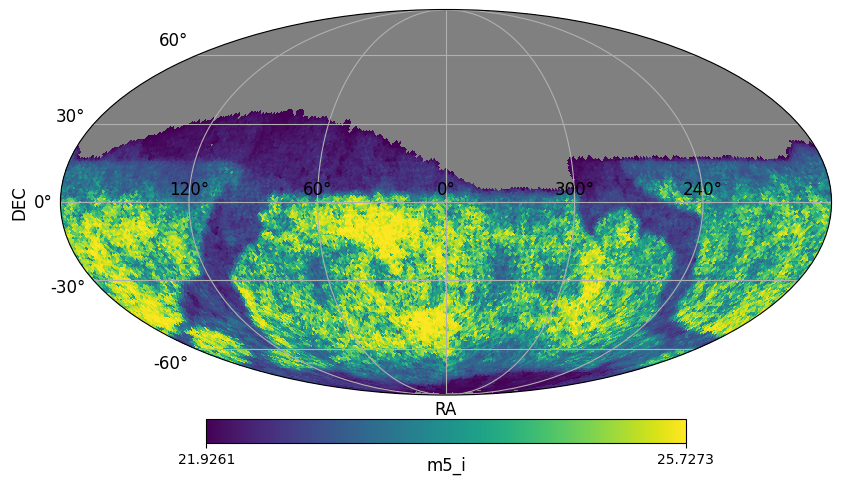

In [3]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'i'
dm.select_band(band)
dm.set_mask()
dm.plot()

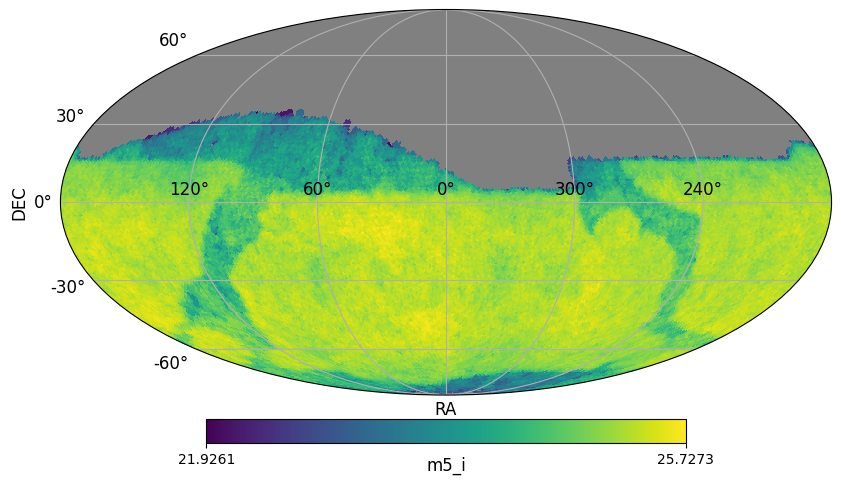

In [4]:
dm.plot(norm=None)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 316.7 (χ²/ndof = 0.0)      │              Nfcn = 741              │
│ EDM = 2.13e-05 (Goal: 0.0002)    │            time = 7.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  24.805   │   0.035   │   -0.035   │   0.035    │    0    │         │       │
│ 1 │ A    │  0.0222   │  0.0027   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │    259    │    25     │    -26     │     25     │    0    │   360   │       │
│ 3 │ dec  │    -79    │     5     │     -5     │     5      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.035   │   0.035   │  -0.0027  │  0.0027   │    -26    │    26     │    -5     │     5     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │   0.00124    -59e-6    0.0844    0.0559 │
│   A │    -59e-6   7.3e-06 -5.470e-3 -3.961e-3 │
│  ra │    0.0844 -5.470e-3       625         5 │
│ dec │    0.0559 -3.961e-3         5      24.8 │
└─────┴─────────────────────────────────────────┘

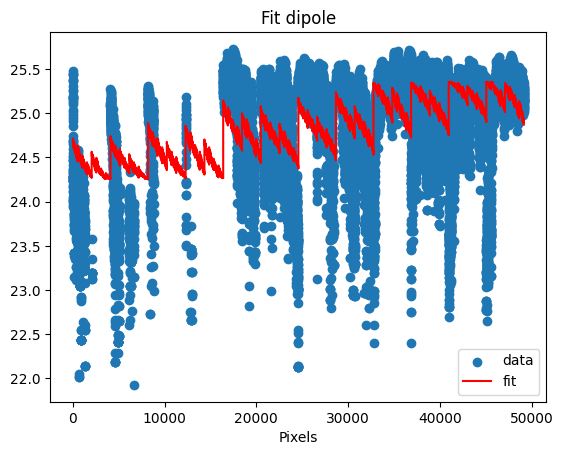

In [5]:
init =  (10, 1, 100, 40)
m = dm.fit_dipole("iMasked", init, plot_map=False)
m

## Ratio determination

In [6]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True)
dataN


Generating redshifts
Number of rejects = 689449
Accepted ratio = 77%

Generating dL
Generating luminosities
Number of rejects = 685236
Accepted ratio = 77%


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
1.1674644147411837,8236.97475971242,1850926151.7005517,-18.338472729015237,26.240365946942752
1.4493204676853078,10749.201591995887,24071117.326232824,-13.623740624249598,31.53314041465152
0.36078560375353574,1991.9409294293714,15972146.454398297,-13.178408209360066,28.31797406749589
0.4689785994855512,2713.6664504092846,11132483.74086155,-12.786480173777347,29.381302153288992
0.4760347496550479,2762.35376881631,689824826.2617813,-17.266847050587558,24.93954943432248
0.3208210852649817,1737.9351964332516,20156144.81566227,-13.431018674915952,27.769149217994382
1.033913835016259,7092.461902630453,19511867.093785774,-13.39574707273425,30.858237985508048
0.5594345908002395,3351.6036047930384,101027807.56244609,-15.181102320811599,27.445160923444263


Saving LumDist in Simul_Figures/Simul_Schechter/Schechter_LumDist.pdf


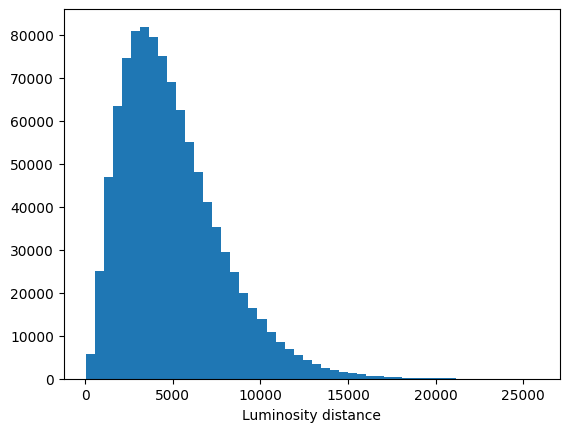

In [7]:
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=50);

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDist")

Saving LumDistLogLog in Simul_Figures/Simul_Schechter/Schechter_LumDistLogLog.pdf


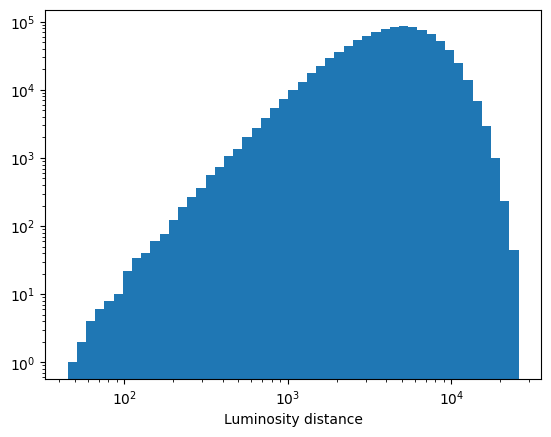

In [8]:
binsdL = np.logspace(np.log10(np.min(dataN["dL"])), np.log10(np.max(dataN["dL"])), 50)
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=binsdL, log=True);
plt.xscale('log')

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDistLogLog")

Saving ApparentMag in Simul_Figures/Simul_Schechter/Schechter_ApparentMag.pdf


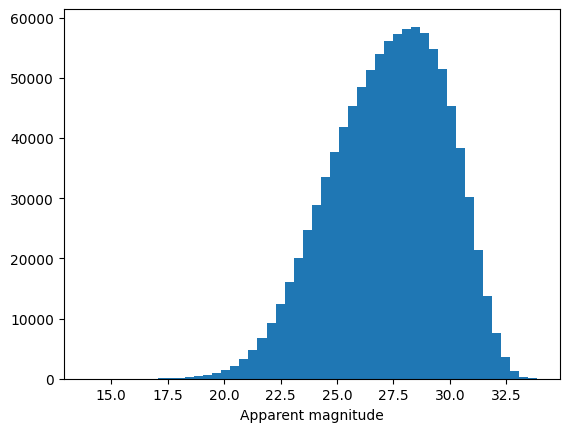

In [9]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$")

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag")

Saving ApparentMag_cut in Simul_Figures/Simul_Schechter/Schechter_ApparentMag_cut.pdf


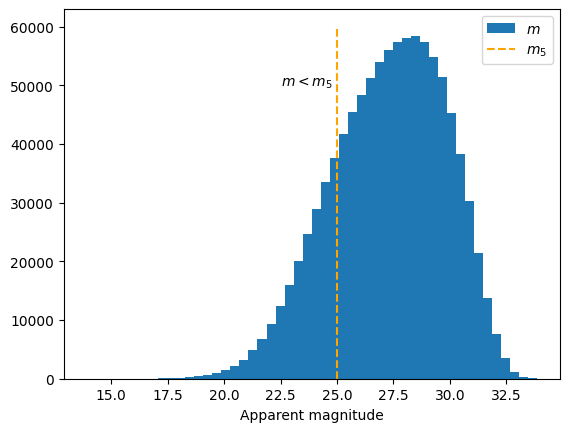

In [10]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$");
plt.vlines(25, 0, 60000, linestyles = 'dashed', colors="orange", label="$m_5$")
plt.text(22.5, 50000, "$m < m_5$")
plt.legend()

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag_cut")

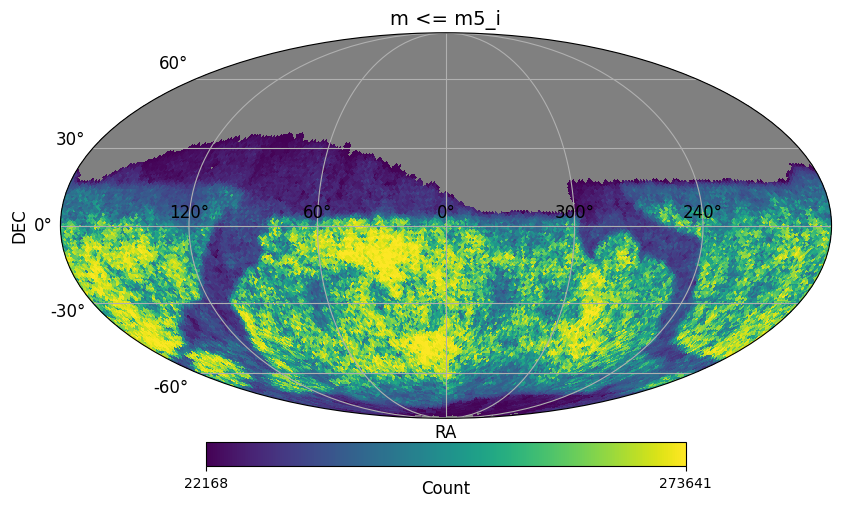

In [11]:
NSource_px = cut_m52map(dataN["m"], dm.m5i.copy())
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= "m <= m5_i")

output_path = "Simul_Figures/Simul_Magnitude/CountMap_m5band_"
#get_savefig(plt, output_path, "i")

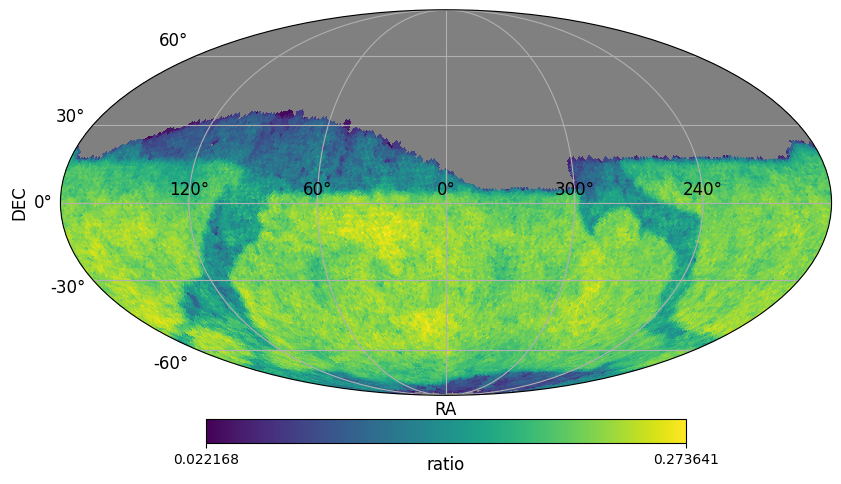

In [12]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'ratio')
ratioMapper.set_mask()
ratioMapper.plot("Masked")

## Souce sampling

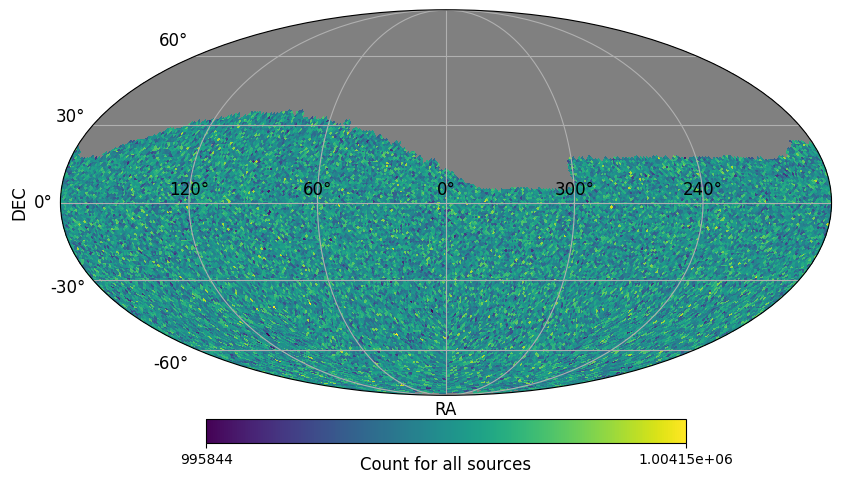

In [13]:
count_thMapper = CountMapper.from_map(np.random.poisson(NSource_px_th, npix))
count_thMapper._set_suffixTextPlot(unit = "all sources")
count_thMapper.set_mask(dm.m5iMasked.mask)
count_thMapper.plot("Masked")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.306e+04 (χ²/ndof = 0.7)  │              Nfcn = 695              │
│ EDM = 0.000263 (Goal: 0.0002)    │            time = 7.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │1.000006e6 │0.000007e6 │-0.000007e6 │ 0.000007e6 │    0    │         │       │
│ 1 │ A    │   4e-6    │   13e-6   │   -4e-6    │   14e-6    │    0    │    1    │       │
│ 2 │ ra   │    70     │    190    │    -70     │    290     │    0    │   360   │       │
│ 3 │ dec  │    -50    │    100    │    -40     │    140     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │   -4e-6   │   14e-6   │    -70    │    290    │    -40    │    140    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────┐
│     │            N*             A            ra           dec │
├─────┼─────────────────────────────────────────────────────────┤
│  N* │          50.9  -56.67589e-6          -190           470 │
│   A │  -56.67589e-6      1.73e-10  311.06312e-6 -771.22954e-6 │
│  ra │          -190  311.06312e-6      6.05e+04      -0.002e6 │
│ dec │           470 -771.22954e-6      -0.002e6      2.61e+04 │
└─────┴─────────────────────────────────────────────────────────┘

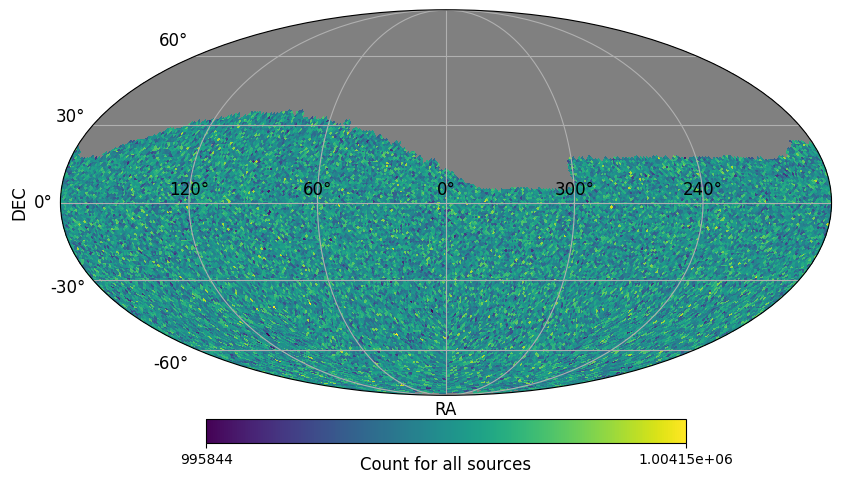

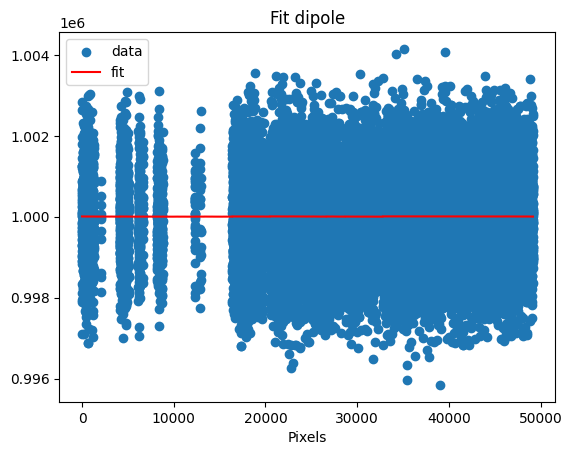

In [14]:
init =  (1e6, 0, 100, 40)
count_thMapper.fit_dipole("Masked", init)

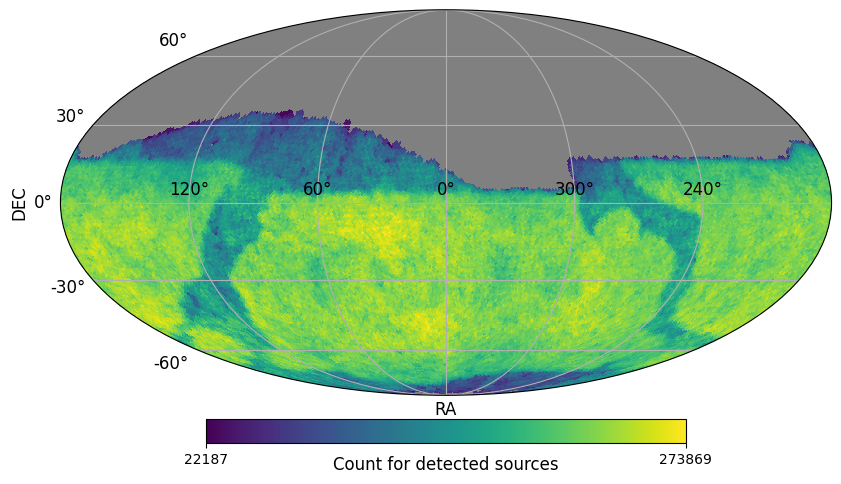

In [15]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.516e+08 (χ²/ndof = 9189.3)│              Nfcn = 504              │
│ EDM = 6.2e-05 (Goal: 0.0002)     │            time = 5.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │167.9405e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │328.899e-3 │ 0.033e-3  │ -0.033e-3  │  0.033e-3  │    0    │    1    │       │
│ 2 │ ra   │  255.252  │   0.020   │   -0.020   │   0.020    │    0    │   360   │       │
│ 3 │ dec  │  -77.716  │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.033e-3 │ 0.033e-3  │   -0.02   │   0.02    │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        7.66 -56.5941e-6      5.5e-3    4.223e-3 │
│   A │ -56.5941e-6    1.12e-09    -58.7e-9    -51.7e-9 │
│  ra │      5.5e-3    -58.7e-9    0.000392    0.001e-3 │
│ dec │    4.223e-3    -51.7e-9    0.001e-3    1.84e-05 │
└─────┴─────────────────────────────────────────────────┘

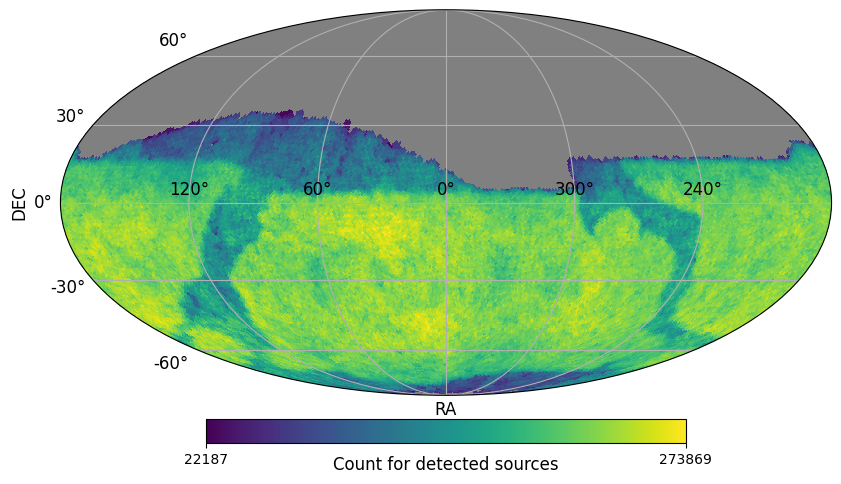

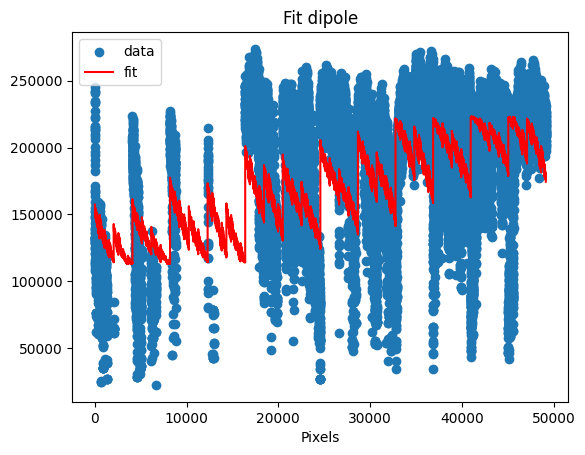

In [16]:
init =  (1e5, 1, 100, 40)
countDetectedMapper.fit_dipole("Masked", init)

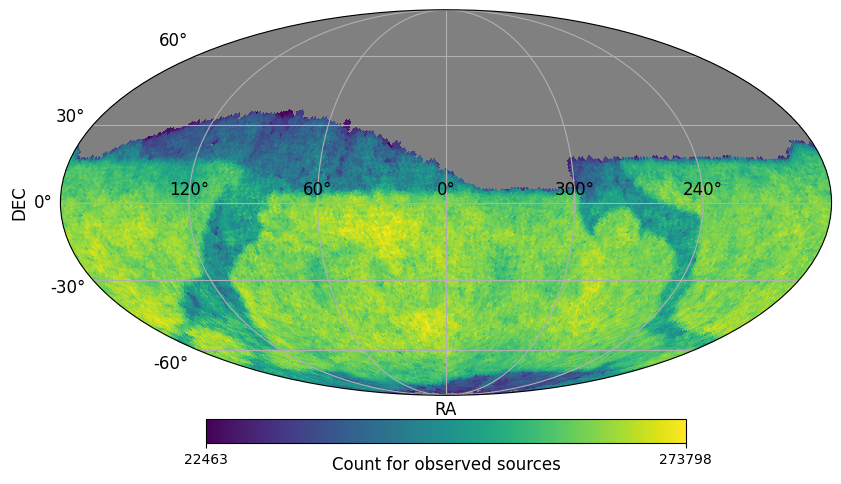

In [17]:
countObservedMapper = CountMapper.from_map(np.random.poisson(countDetectedMapper.map))
countObservedMapper._set_suffixTextPlot(unit = "observed sources")
countObservedMapper.set_mask(dm.m5iMasked.mask)
countObservedMapper.plot("Masked")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.517e+08 (χ²/ndof = 9191.5)│              Nfcn = 504              │
│ EDM = 6.23e-05 (Goal: 0.0002)    │            time = 5.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │167.9328e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │328.969e-3 │ 0.033e-3  │ -0.033e-3  │  0.033e-3  │    0    │    1    │       │
│ 2 │ ra   │  255.245  │   0.020   │   -0.020   │   0.020    │    0    │   360   │       │
│ 3 │ dec  │  -77.722  │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.033e-3 │ 0.033e-3  │   -0.02   │   0.02    │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        7.66 -56.5996e-6      5.5e-3    4.221e-3 │
│   A │ -56.5996e-6    1.12e-09    -58.7e-9    -51.7e-9 │
│  ra │      5.5e-3    -58.7e-9    0.000393    0.001e-3 │
│ dec │    4.221e-3    -51.7e-9    0.001e-3    1.84e-05 │
└─────┴─────────────────────────────────────────────────┘

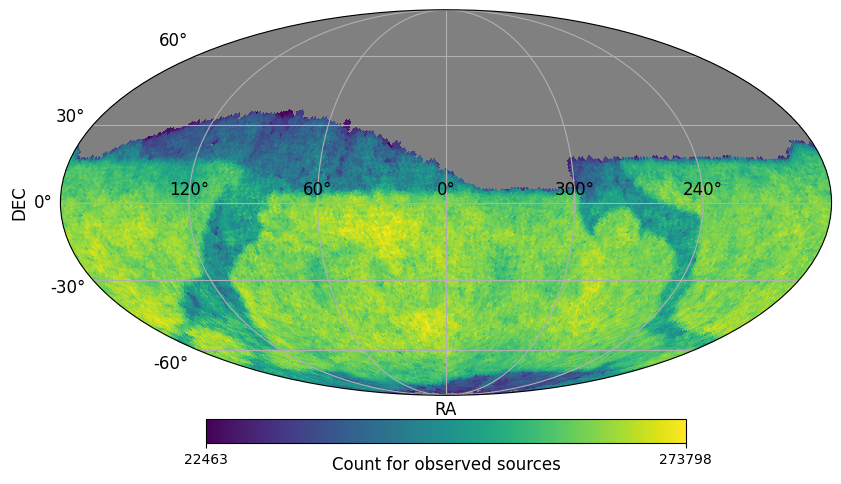

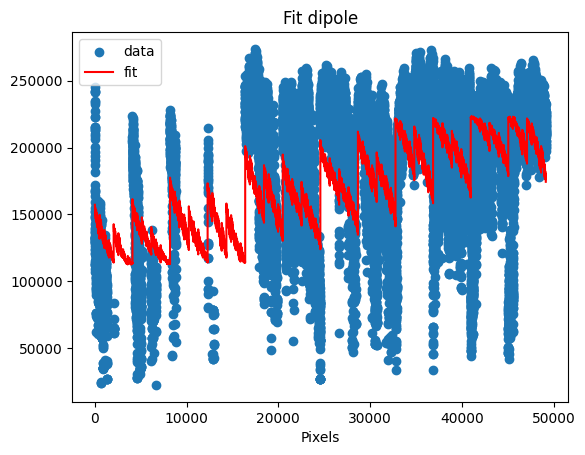

In [18]:
init =  (1e5, 1, 100, 40)
countObservedMapper.fit_dipole("Masked", init)

/tmp/ipykernel_24432/2547980425.py:1: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


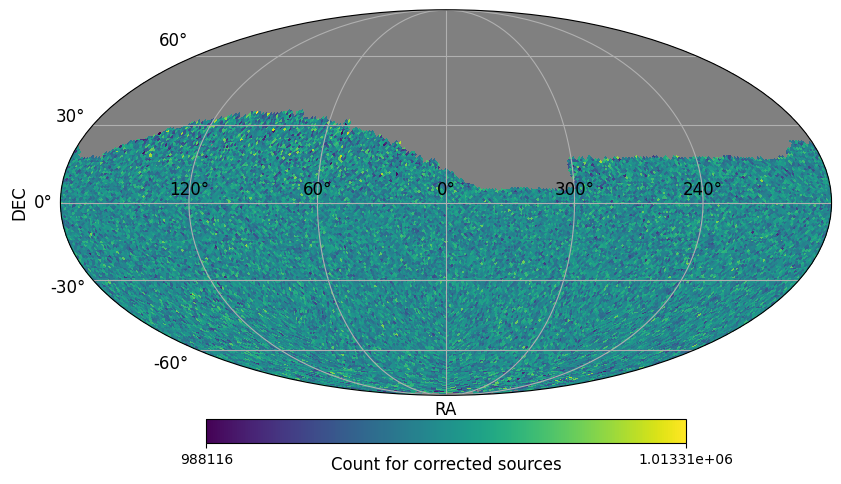

In [19]:
countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
countCorrectedMapper.fillna()
countCorrectedMapper._set_suffixTextPlot(unit = "corrected sources")
countCorrectedMapper.set_mask()
countCorrectedMapper.plot("Masked")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.187e+05 (χ²/ndof = 4.4)  │              Nfcn = 401              │
│ EDM = 3e-05 (Goal: 0.0002)       │            time = 4.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 999.974e3 │  0.007e3  │  -0.007e3  │  0.007e3   │    0    │         │       │
│ 1 │ A    │ 0.054e-3  │ 0.014e-3  │ -0.014e-3  │  0.014e-3  │    0    │    1    │       │
│ 2 │ ra   │    109    │    28     │    -31     │     29     │    0    │   360   │       │
│ 3 │ dec  │    -70    │    10     │     -9     │     10     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │ -0.014e-3 │ 0.014e-3  │    -31    │    29     │    -9     │    10     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │         50.4 -62.10297e-6           -0           10 │
│   A │ -62.10297e-6     1.92e-10   4.28105e-6 -18.71245e-6 │
│  ra │           -0   4.28105e-6          822           10 │
│ dec │           10 -18.71245e-6           10         91.5 │
└─────┴─────────────────────────────────────────────────────┘

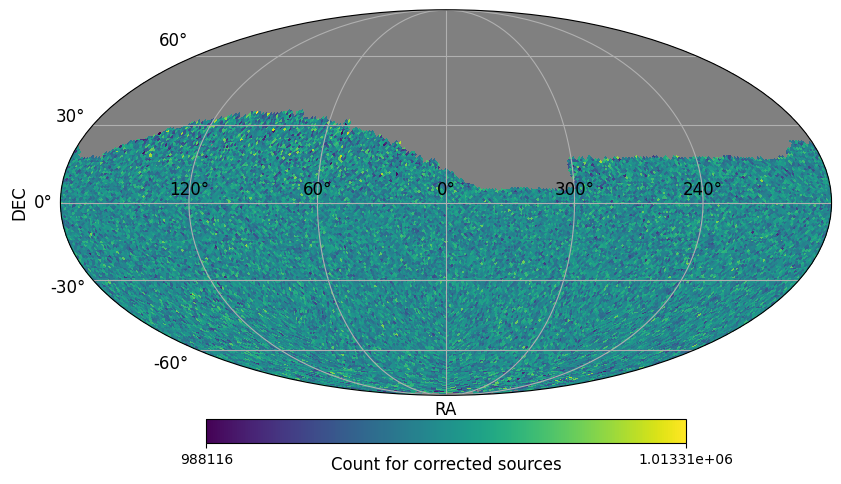

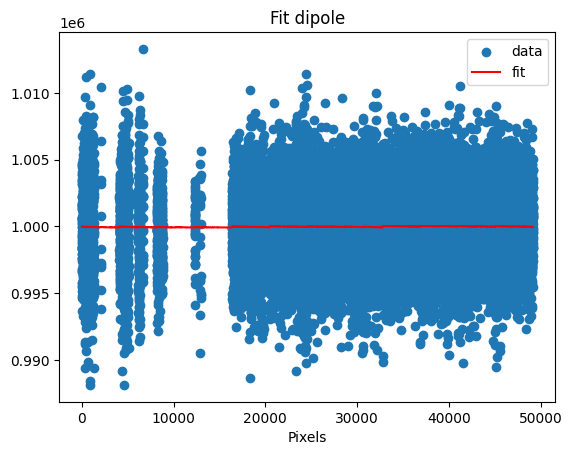

In [20]:
init =  (1e6, 0, 100, 40)
countCorrectedMapper.fit_dipole("Masked", init)